In [1]:
! pip install -q kaggle

In [2]:
from google.colab import files

In [3]:
files.upload()

Saving kaggle (4).json to kaggle (4).json


{'kaggle (4).json': b'{"username":"faridbazar","key":"ecd4d06767c708f8d1c12494d07f546c"}'}

In [4]:
! mkdir ~/.kaggle

In [5]:
! cp kaggle.json ~/.kaggle/

In [6]:
! chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d muratkokludataset/rice-image-dataset

Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
 95% 208M/219M [00:02<00:00, 104MB/s]
100% 219M/219M [00:02<00:00, 99.7MB/s]


In [8]:
!unzip rice-image-dataset.zip -d rice

Streaming output truncated to the last 5000 lines.
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (5509).jpg  
  inflating: rice/Rice_Image_Dataset/Karacadag/Karacadag (551).jpg  
  inflating: rice/Rice_Image_Dataset/Karaca

In [2]:
import os
import pandas as pd

In [3]:
df = pd.DataFrame([],columns=['path','label'])

In [4]:
len(df)

0

In [5]:
class_dict = {'Karacadag':0,'Arborio':1,'Ipsala':2,'Basmati':3,'Jasmine':4}
df = pd.DataFrame([],columns=['path','label'])

main_path = '/content/rice/Rice_Image_Dataset'
for class_name in os.listdir(main_path):
  if not '.txt' in class_name:
    print(class_name)
    class_path =os.path.join(main_path,class_name)
    for image_name in os.listdir(class_path):
      df.loc[len(df)] = [os.path.join(class_path,image_name),class_dict[class_name]]

    # print(len(os.listdir()))

Karacadag
Arborio
Ipsala
Basmati
Jasmine


In [6]:
df['path'][0]

'/content/rice/Rice_Image_Dataset/Karacadag/Karacadag (1086).jpg'

In [7]:
import cv2
import numpy as np

In [8]:
img = cv2.imread('/content/rice/Rice_Image_Dataset/Karacadag/Karacadag (1086).jpg')

In [9]:
img.shape

(250, 250, 3)

In [10]:
50*50*3*75000*4

2250000000

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
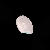

In [12]:
cv2.resize(img,(50,50))

In [11]:
array_list = []
for image_path in df['path']:
  img = cv2.imread(image_path)
  img = cv2.resize(img,(40,40))
  img = np.array(img,dtype=np.float32)
  img = img/255

  array_list.append(img[:,:,::-1])
  del img
array_list = np.array(array_list)

In [16]:
array_list.shape

(75000, 50, 50, 3)

In [12]:
array_list = np.array(array_list,dtype=np.float32)

In [13]:
2100 * 200 * 200 *3 *4

1008000000

In [14]:
import matplotlib.pyplot as plt


In [15]:
array_list[400]

array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.00392157, 0.00392157, 0.00392157],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0

In [16]:
array_list.shape

(75000, 40, 40, 3)

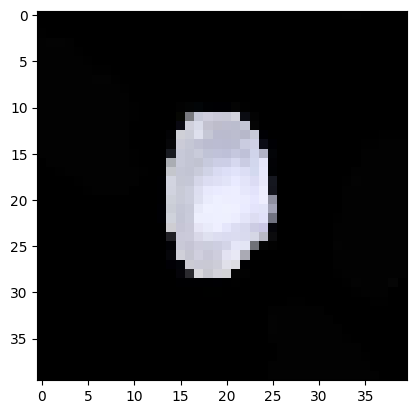

In [17]:
plt.imshow(array_list[400]);

In [1]:
import numpy as np

In [2]:
with open('images.npy', 'rb') as f:
    array_list = np.load(f)


In [3]:
with open('label.npy', 'rb') as f:
    y = np.load(f)


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
def onehot(arr):
  return np.eye(5)[arr]

In [7]:
X = array_list
# y = onehot(df['label'].values)
y = onehot(y)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3,random_state=101,shuffle=True)

In [9]:
y_train[0]

array([0., 1., 0., 0., 0.])

In [10]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [11]:
def init_weights(shape):
    init_random_dist = tf.truncated_normal(shape, stddev=0.1)
    return tf.Variable(init_random_dist)

def init_bias(shape):
    init_bias_vals = tf.constant(0.1, shape=shape)
    return tf.Variable(init_bias_vals)

def conv2d(x, W):
    return tf.nn.conv2d(x, W, strides=[1, 1, 1, 1],
                        padding='SAME')

def max_pool_2by2(x):
    return tf.nn.max_pool(x, ksize=[1, 2, 2, 1],
                          strides=[1, 2, 2, 1],
                          padding='SAME')

def convolutional_layer(input_x, shape):
    W = init_weights(shape)
    b = init_bias([shape[3]])
    return tf.nn.relu(conv2d(input_x, W) + b)

def normal_full_layer(input_layer, size):
    input_size = int(input_layer.get_shape()[1])
    W = init_weights([input_size, size])
    b = init_bias([size])
    return tf.matmul(input_layer, W) + b

In [12]:
x = tf.placeholder(tf.float32,shape=[None,40,40,3])
y_true = tf.placeholder(tf.float32,shape=[None,5])

In [13]:
hold_prob = tf.placeholder(tf.float32)

In [14]:
convo_1 = convolutional_layer(x,shape=[4,4,3,32])
convo_1_pooling = max_pool_2by2(convo_1)

In [15]:
convo_2 = convolutional_layer(convo_1_pooling,
                              shape=[3,3,32,64])
convo_2_pooling = max_pool_2by2(convo_2)

In [16]:
# convo_3 = convolutional_layer(convo_2_pooling,
#                               shape=[5,5,64,64])
# convo_3_pooling = max_pool_2by2(convo_3)

In [39]:
convo_3_flat = tf.reshape(convo_2_pooling,[-1,10*10*64])

In [18]:
10*10*64*1000

6400000

In [19]:
X_train.shape

(52500, 40, 40, 3)

In [40]:
full_layer_one = tf.nn.relu(normal_full_layer(convo_3_flat,
                                              1000))
full_one_dropout = tf.nn.dropout(full_layer_one,
                                 keep_prob=hold_prob)

In [41]:
full_layer_two = tf.nn.relu(normal_full_layer(full_one_dropout,
                                              100))


In [42]:
y_pred = normal_full_layer(full_layer_two,5)

In [43]:
cross_entropy = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits_v2(
        labels=y_true,logits=y_pred))

In [44]:
optimizer = tf.train.AdamOptimizer(learning_rate=0.001)
train = optimizer.minimize(cross_entropy)

In [45]:
lateast_bid = 0

In [46]:
def next_batch(batch_size = 100):
  global lateast_bid
  x_batch = X_train[lateast_bid:lateast_bid+batch_size]
  y_batch = y_train[lateast_bid:lateast_bid+batch_size]
  if lateast_bid+ batch_size <= len(X_train):
   lateast_bid  += batch_size
  else :
    lateast_bid = 0
  return x_batch , y_batch


In [47]:
next_batch()

(array([[[[0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         [[0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         [[0.00392157, 0.00392157, 0.00392157],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         ...,
 
         [[0.        , 0.        , 0.        ],
          [0.     

In [48]:
init = tf.global_variables_initializer()

In [49]:
lateast_bid = 0

In [50]:
saver = tf.train.Saver()

In [51]:
_,y_batch = next_batch(2)
y_batch

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [52]:
y_pred.shape

TensorShape([Dimension(None), Dimension(5)])

In [53]:
with tf.Session() as sess:
    sess.run(init)

    for i in range(500):
        batch = next_batch(100)
        sess.run(train, feed_dict={x: batch[0],
                                   y_true: batch[1],
                                   hold_prob: 0.5})

        # PRINT OUT A MESSAGE EVERY 100 STEPS
        if i%100 == 0:

            print('Currently on step {}'.format(i))
            print('Accuracy is:')
            # Test the Train Model
            matches = tf.equal(tf.argmax(y_pred,1),
                               tf.argmax(y_true,1))

            acc = tf.reduce_mean(tf.cast(matches,tf.float32))

            print(sess.run(acc,feed_dict={
                x: X_test,
                y_true: y_test,
                hold_prob:1.0}))
            print('\n')
    print('Currently on step {}'.format(i))
    print('Accuracy is:')
    # Test the Train Model
    matches = tf.equal(tf.argmax(y_pred,1),
                       tf.argmax(y_true,1))

    acc = tf.reduce_mean(tf.cast(matches,tf.float32))

    print(sess.run(acc,feed_dict={
        x: X_test,
        y_true: y_test,
        hold_prob:1.0}))
    saver.save(sess,'new_models/my_4th_model.ckpt')
    print('\n')

Currently on step 0
Accuracy is:
0.20004444


Currently on step 100
Accuracy is:
0.9421333


Currently on step 200
Accuracy is:
0.96537775


Currently on step 300
Accuracy is:
0.9677333


Currently on step 400
Accuracy is:
0.9703556


Currently on step 499
Accuracy is:
0.9747111




In [53]:
# with open('images.npy', 'wb') as f:
#     np.save(f,array_list)


In [54]:
# with open('label.npy', 'wb') as f:
#     np.save(f,df['label'].values)


[1. 0.]


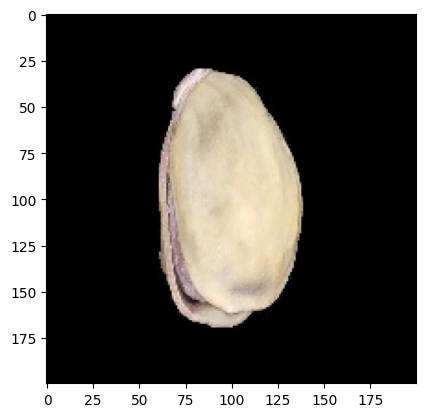

In [ ]:
print(y_test[0])
plt.imshow(X_test[0])

In [ ]:
with tf.Session() as sess:
#     sess.run(init)
    # Restore the model
    saver.restore(sess,tf.train.latest_checkpoint("new_models"))
    pred = sess.run(y_pred,feed_dict={x:[X_test[0]],hold_prob:1.0})

In [ ]:
pred.argmax()

1

In [ ]:
y_test

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])